In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.6 MB/s eta 0:00:00


In [ ]:
import cv2
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO('yolov8n.pt')

In [ ]:
result= model("cat_dog2.jpg")


image 1/1 /content/cat_dog2.jpg: 384x640 1 cat, 1 dog, 71.6ms
Speed: 11.2ms preprocess, 71.6ms inference, 39.5ms postprocess per image at shape (1, 3, 384, 640)


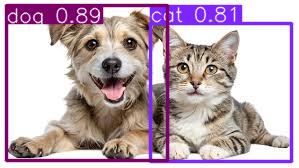

In [ ]:
result[0].show()

In [ ]:
from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

name 'take_photo' is not defined


In [23]:
# camera=cv2.VideoCapture(0)
# while True:
#   ret,frame= camera.read()
#   if not ret:
#     break
#   results= model(frame,verbose=False)
#   plot_frame= result[0].plot()

#   cv2.imshow("Yolo",plot_frame)
#   if cv2.waitKey(1) & 0xFF == ord("q"):
#     break
# camera.release()
# cv2.destroyAllWindows()

### 1. Setup Utilities and Imports
This cell handles the imports and the helper functions needed to convert images between the JavaScript webcam format and OpenCV.

In [ ]:
from IPython.display import Image, display
try:
    filename = take_photo()
    print('Saved to {}'.format(filename))
    frame = cv2.imread(filename)
    result = model(frame, verbose=False)
    plot_frame = result[0].plot()
    cv2.imwrite(filename, plot_frame)
    display(Image(filename))
except Exception as err:
    print(str(err))

name 'take_photo' is not defined


In [ ]:
from IPython.display import display, Javascript, Image, clear_output
from google.colab import output
import base64, numpy as np, cv2

def process_frame(img_data):
    img_bytes  = base64.b64decode(img_data.split(',')[1])
    img_array  = np.frombuffer(img_bytes, dtype=np.uint8)
    frame      = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    result     = model(frame, verbose=False)
    plot_frame = result[0].plot()
    _, buffer  = cv2.imencode('.jpg', plot_frame)
    clear_output(wait=True)
    display(Image(data=buffer.tobytes()))

output.register_callback('notebook.process_frame', process_frame)

display(Javascript('''
    async function startVideo() {
        const video = document.createElement('video');
        video.style.display = 'none';
        document.body.appendChild(video);
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        video.srcObject = stream;
        await video.play();
        setInterval(() => {
            const canvas = document.createElement('canvas');
            canvas.width  = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            const imgData = canvas.toDataURL('image/jpeg', 0.5);
            google.colab.kernel.invokeFunction('notebook.process_frame', [imgData], {});
        }, 200);
    }
    startVideo();
'''))

<IPython.core.display.Javascript object>

In [ ]:
from IPython.display import display, Javascript, Image
from google.colab import output
import base64, numpy as np, cv2

# Create a placeholder that gets updated in place
display_handle = display(None, display_id=True)

def process_frame(img_data):
    img_bytes  = base64.b64decode(img_data.split(',')[1])
    img_array  = np.frombuffer(img_bytes, dtype=np.uint8)
    frame      = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    result     = model(frame, verbose=False)
    plot_frame = result[0].plot()
    _, buffer  = cv2.imencode('.jpg', plot_frame)
    display_handle.update(Image(data=buffer.tobytes()))  # updates live

output.register_callback('notebook.process_frame', process_frame)

display(Javascript('''
    async function startVideo() {
        const video = document.createElement('video');
        video.style.display = 'none';
        document.body.appendChild(video);
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        video.srcObject = stream;
        await video.play();
        setInterval(() => {
            const canvas = document.createElement('canvas');
            canvas.width  = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            const imgData = canvas.toDataURL('image/jpeg', 0.5);
            google.colab.kernel.invokeFunction('notebook.process_frame', [imgData], {});
        }, 200);
    }
    startVideo();
'''))